<div align="center">Counter-Electrode Dependence of the Working-Electrode Capacitance in Three-Electrode TiO2 + rGO Cells: Classical Controls and Interpretation within a Quantum-Discord Framework</div>
<br>
<div align="center">Kevin A. Gonzalez, Nicolás H. Toledo, and David A. Miranda
<br>Universidad Industrial de Santander, 680002 Bucaramanga, Santander, Colombia</div>

## 1. Description

This notebook validates the released Excel exports and reproduces the data-driven main-text and Supplementary Material figures from those files. The public data include the author-selected raw exports for 10 valid TiO2+rGO bars organized into five pairs, plus the dummy-control exports. The pairs were formed because the individual Configuration 1 characterizations with Pt as CE produced comparable spectra. The notebook uses reusable functions from `scr/eis_figures.py`, relative paths rooted at `data/`, and creates no figure-output directory by default.

The plots document macroscopic EIS responses and controls. For capacitance figures, the workflow uses the `C' (F)` and `C'' (F)` columns calculated and exported directly by the potentiostat; it does not recalculate plotted experimental capacitance components from impedance. The capacitance convention is `C^* = C' - jC''`, and impedance is denoted as the measured quantity `Z_m`. The plots do not directly measure quantum discord or entanglement, and no new fit, statistical analysis, or sample-selection rule is introduced here.

In [1]:
from copy import deepcopy
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

from scr.eis_figures import (
    plot_figure_4,
    plot_figure_5,
    plot_figure_6,
    plot_figure_7,
    plot_supplementary_figure_1,
    plot_supplementary_figure_2,
    plot_supplementary_figure_3,
    plot_supplementary_figure_4,
    validate_raw_dataset,
    verify_raw_hashes,
)
from scr.figure_styles import FIGURE_STYLES

DATA_ROOT = Path("data")

Matplotlib is building the font cache; this may take a moment.


## 2. Figure style configuration

The editable defaults are stored in `scr/figure_styles.py` as `FIGURE_STYLES`. This notebook keeps only a compact `figure_config(...)` helper for local per-figure overrides. Use `show_marker`, `marker_fill`, `show_line`, `linestyle`, colors, labels, and legend options there to test figure variants without changing the raw data or plotting functions. Figures 5-7 and S1-S4 combine a capacitance Nyquist panel at left with two capacitance Bode panels at right; Figure 4 is unchanged. The dummy-cell resonance line is shown only in Figure 7 by default and can be toggled with `SHOW_FIGURE_7_DUMMY_FREQUENCY`.


In [2]:
# Figure style presets live in scr/figure_styles.py. Keep this notebook compact by
# editing only local per-figure overrides here when needed.
#
# Example: test marker/line/fill options in one figure.
# figure = plot_figure_6(
#     DATA_ROOT,
#     style=figure_config(
#         "figure_6",
#         {
#             "series": {
#                 "configuration_1": {
#                     "color": "tab:blue",
#                     "marker": "s",
#                     "show_marker": True,
#                     "marker_fill": True,
#                     "show_line": True,
#                     "linestyle": "--",
#                 },
#                 "configuration_3": {
#                     "color": "tab:orange",
#                     "marker": "^",
#                     "show_marker": False,
#                     "show_line": True,
#                     "linestyle": ":",
#                 },
#             },
#             "legend": {"show": True, "kwargs": {"fontsize": 8, "frameon": False}},
#         },
#     ),
# )
#
SHOW_FIGURE_7_DUMMY_FREQUENCY = True

# Example: enable the available Pt-CE reference series only in Figure 7.
# figure = plot_figure_7(
#     DATA_ROOT,
#     style=figure_config("figure_7", {"series": {"configuration_1_pt_ce": {"show": True}}}),
# )

def merge_style(base, overrides):
    result = deepcopy(base)
    for key, value in overrides.items():
        if isinstance(value, dict) and isinstance(result.get(key), dict):
            result[key] = merge_style(result[key], value)
        else:
            result[key] = value
    return result


def figure_config(name, overrides=None):
    style = deepcopy(FIGURE_STYLES[name])
    if overrides:
        style = merge_style(style, overrides)
    return style


## 3. Raw-data validation

The next cell checks the expected 23-file coverage, required columns, numeric values, missing cells, row counts, descending frequencies, acquired ranges, and SHA-256 digests before any figure is generated.

In [3]:
raw_summary = validate_raw_dataset(DATA_ROOT)
hash_summary = verify_raw_hashes(DATA_ROOT, DATA_ROOT / "raw_sha256.csv")
print(f"Validated {len(raw_summary)} exports; SHA-256 matches: {hash_summary['matches'].sum()}/{len(hash_summary)}")
display(raw_summary)

Validated 23 exports; SHA-256 matches: 23/23


,relative_path,rows,frequency_max_hz,frequency_min_hz
0,Main_Fig4/R 10kOhm - C 1microFarad.xlsx,60,100000.0,0.1
1,Main_Fig4/R 10kOhm.xlsx,60,100000.0,0.1
2,Main_Fig4/R 1kOhm - C 1microFarad.xlsx,60,100000.0,0.1
3,Main_Fig4/R 1kOhm.xlsx,60,100000.0,0.1
4,Main_Fig4/R 3kOhm - C 1microFarad.xlsx,60,100000.0,0.1
5,Main_Fig4/R 3kOhm.xlsx,60,100000.0,0.1
6,Main_Fig4/R 47kOhm.xlsx,60,100000.0,0.1
7,Main_Fig4/Sin protoboard.xlsx,60,100000.0,0.1
8,Main_Fig5/Configuration1_Bar1WE.xlsx,80,1000000.0,0.1
9,Main_Fig5/Configuration1_Bar2WE.xlsx,80,1000000.0,0.1


## 4. Figure map

| Manuscript item | Source data | Imported function | Status |
|---|---|---|---|
| Figure 1 | — | — | Experimental setup photograph; not data-generated and not reproduced |
| Figures 2–3 | — | — | Experimental cell diagrams; not data-generated and not reproduced |
| Figure 4 | `data/Main_Fig4/*.xlsx` | `plot_figure_4` | Reproduced from eight exports plus the coded dummy-cell reference model |
| Figure 5 | `data/Main_Fig5/*.xlsx` | `plot_figure_5` | Reproduced; equivalent capacitance is derived in memory |
| Figure 6 | `data/Main_Fig6-7/Configuration 1.xlsx` and `Configuration 3.xlsx` | `plot_figure_6` | Reproduced |
| Figure 7 | `data/Main_Fig6-7/Configuration 3 + dummy on CE.xlsx`, `Configuration 3.xlsx`, `Configuration 2 + dummy on CE.xlsx`; optional `Configuration 1.xlsx` | `plot_figure_7` | Reproduced |
| Figures S1–S4 | corresponding `data/Supplementary_Fig*/` directory | `plot_supplementary_figure_1` … `_4` | Reproduced |

Exact filenames and historical display-point selections are recorded in `data/figure_provenance.csv`. The complete acquired series remain in the released Excel files.

## 5. Main Figure 4 — Potentiostat and dummy-cell validation

**Sources:** all eight exports in `data/Main_Fig4/`. **Function:** `plot_figure_4`. All 60 points are plotted. The semicircle reference model and small point offsets used solely for visual separation are generated in code.

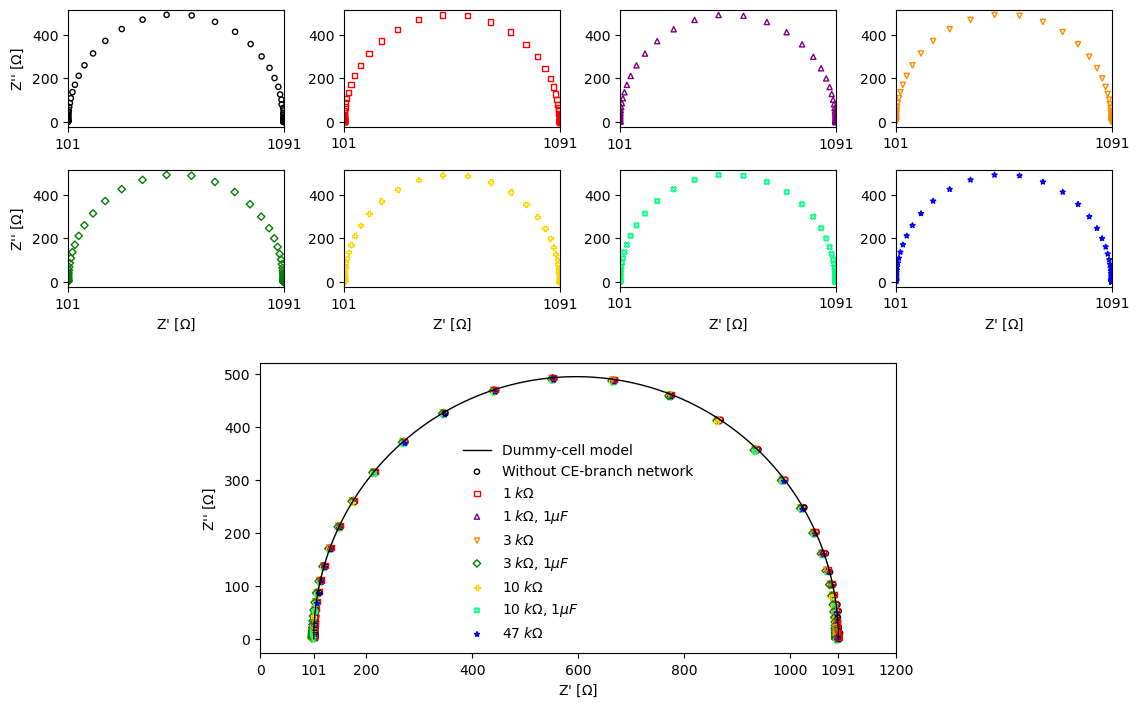

In [4]:
figure = plot_figure_4(DATA_ROOT, style=figure_config("figure_4"))
plt.show()

## 6. Main Figure 5 — Classical two-electrode control

**Sources:** the three exports in `data/Main_Fig5/`. **Function:** `plot_figure_5`. The first 78 points of each 80-point series are displayed. The equivalent response is calculated as $C_{eq}=C_1C_2/(C_1+C_2)$ from the two independently characterized Configuration 1 exports. The right-side Bode panels plot C' and C'' versus frequency with a common logarithmic x-axis and autoscaled y-axes.

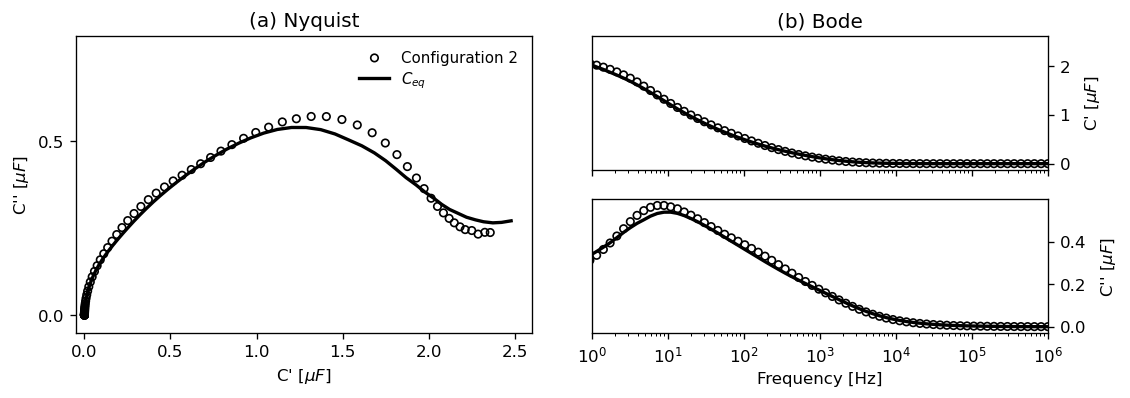

In [5]:
figure = plot_figure_5(DATA_ROOT, style=figure_config("figure_5"))
plt.show()

## 7. Main Figure 6 — Counter-electrode-dependent capacitance

**Sources:** `data/Main_Fig6-7/Configuration 1.xlsx` and `Configuration 3.xlsx`. **Function:** `plot_figure_6`. The historical display uses the first 67 and 66 points, respectively, from the complete 80-point exports. The right-side Bode panels plot C' and C'' versus frequency with a common logarithmic x-axis and autoscaled y-axes.

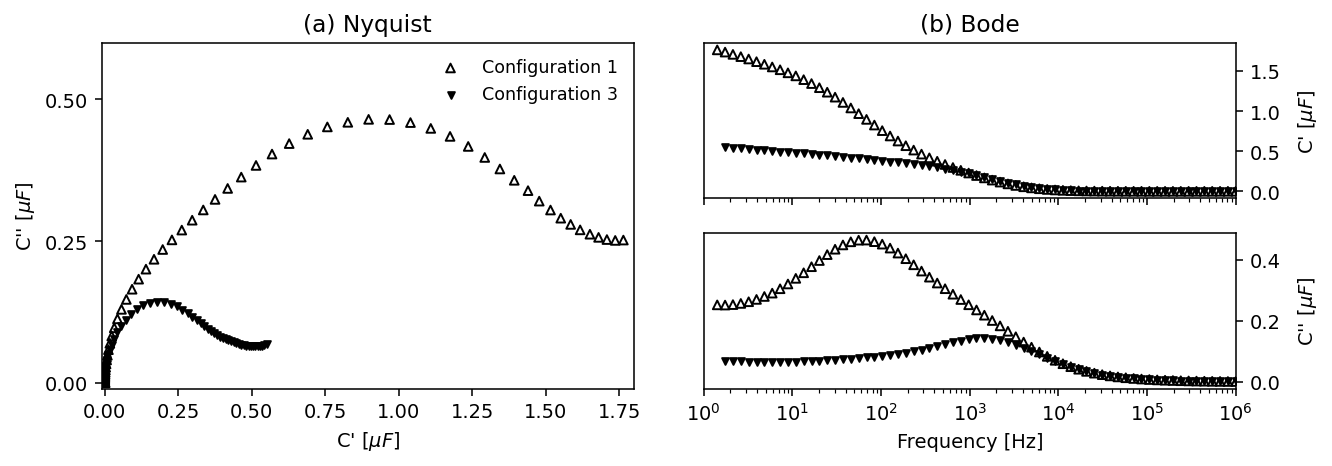

In [6]:
figure = plot_figure_6(DATA_ROOT, style=figure_config("figure_6"))
plt.show()

## 8. Main Figure 7 — Passive dummy-cell control

**Sources:** `data/Main_Fig6-7/Configuration 3 + dummy on CE.xlsx`, `Configuration 3.xlsx`, and `Configuration 2 + dummy on CE.xlsx`. **Function:** `plot_figure_7`. The historical display uses the first 67, 66, and 69 points for the three Figure 7 cell exports. The dummy-cell measurement is not plotted; the Bode panels only include the vertical dummy resonance marker. The upper and lower panels plot C' and C'' versus frequency. The available Configuration 1 Pt-CE series can be enabled through `configuration_1_pt_ce` in `FIGURE_STYLES`.

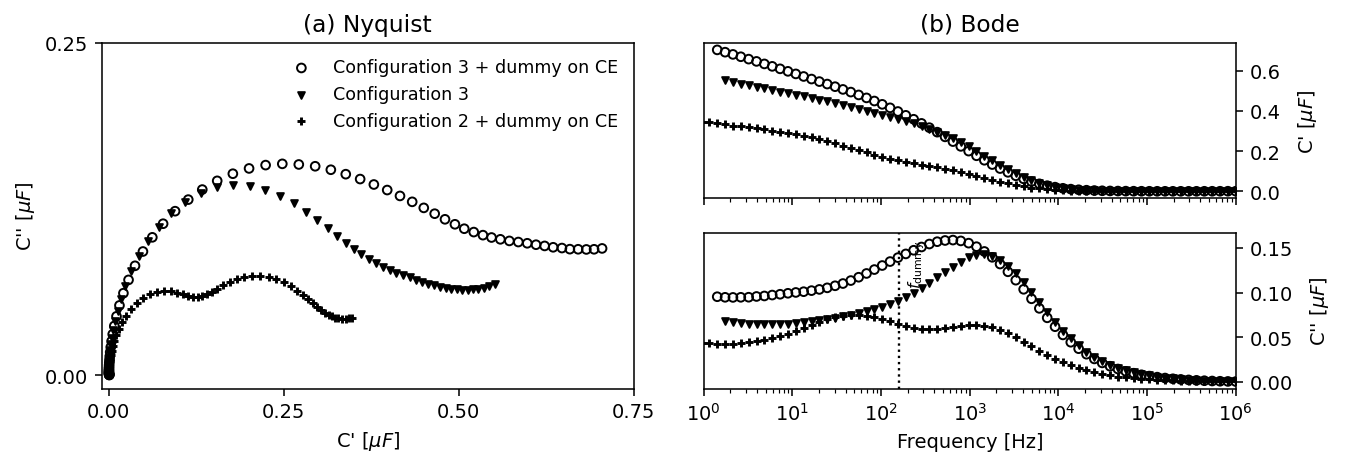

In [7]:
figure = plot_figure_7(
    DATA_ROOT,
    style=figure_config("figure_7", {"bode": {"dummy_resonance": {"show": SHOW_FIGURE_7_DUMMY_FREQUENCY}}}),
)
plt.show()


## 9. Supplementary Figure S1

**Sources:** `data/Supplementary_Fig1/Configuration1.xlsx` and `Configuration3.xlsx`. **Function:** `plot_supplementary_figure_1`. The first 71 and 73 points are displayed. The right-side Bode panels plot C' and C'' versus frequency with a common logarithmic x-axis and autoscaled y-axes.

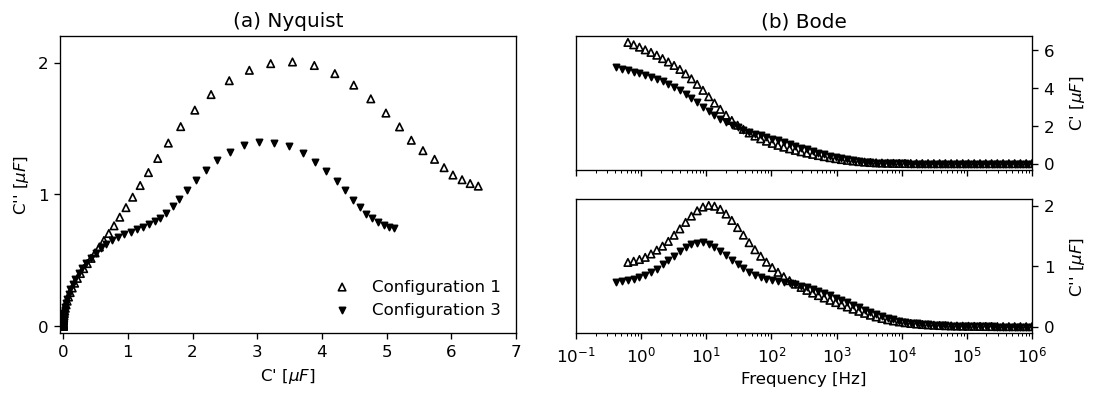

In [8]:
figure = plot_supplementary_figure_1(DATA_ROOT, style=figure_config("supplementary_pair"))
plt.show()

## 10. Supplementary Figure S2

**Sources:** `data/Supplementary_Fig2/Configuration1.xlsx` and `Configuration3.xlsx`. **Function:** `plot_supplementary_figure_2`. The first 70 points of both complete series are displayed. The right-side Bode panels plot C' and C'' versus frequency with a common logarithmic x-axis and autoscaled y-axes.

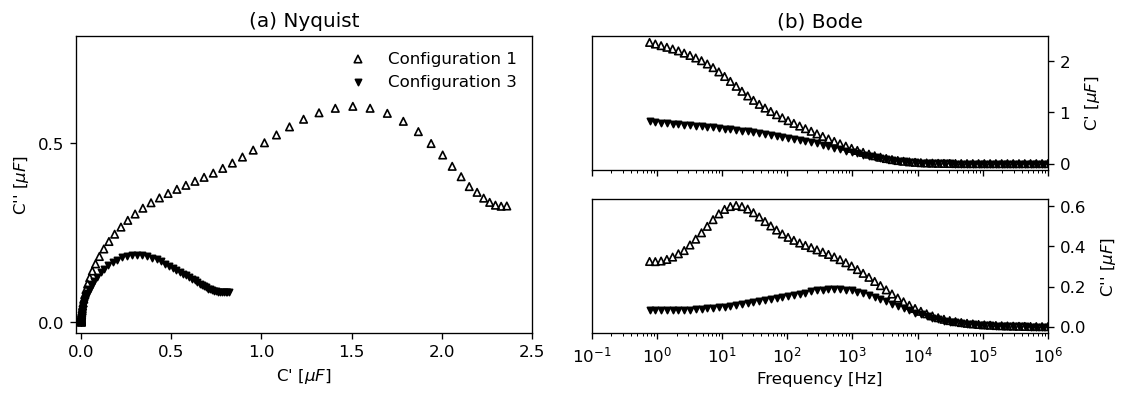

In [9]:
figure = plot_supplementary_figure_2(DATA_ROOT, style=figure_config("supplementary_pair"))
plt.show()

## 11. Supplementary Figure S3

**Sources:** `data/Supplementary_Fig3/Configuration1.xlsx` and `Configuration3.xlsx`. **Function:** `plot_supplementary_figure_3`. All 80 points of both series are displayed. The right-side Bode panels plot C' and C'' versus frequency with a common logarithmic x-axis and autoscaled y-axes.

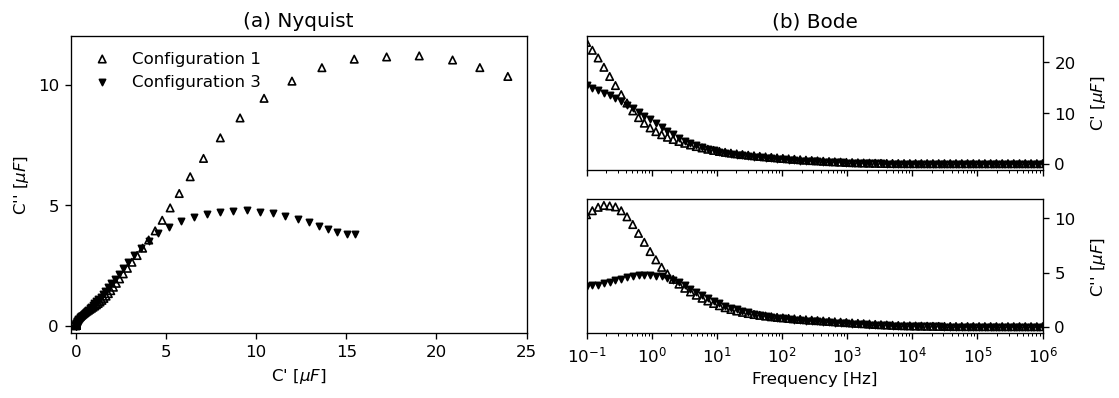

In [10]:
figure = plot_supplementary_figure_3(DATA_ROOT, style=figure_config("supplementary_pair"))
plt.show()

## 12. Supplementary Figure S4

**Sources:** `data/Supplementary_Fig4/Configuration1.xlsx` and `Configuration3.xlsx`. **Function:** `plot_supplementary_figure_4`. The first 65 and 75 points are displayed. The right-side Bode panels plot C' and C'' versus frequency with a common logarithmic x-axis and autoscaled y-axes.

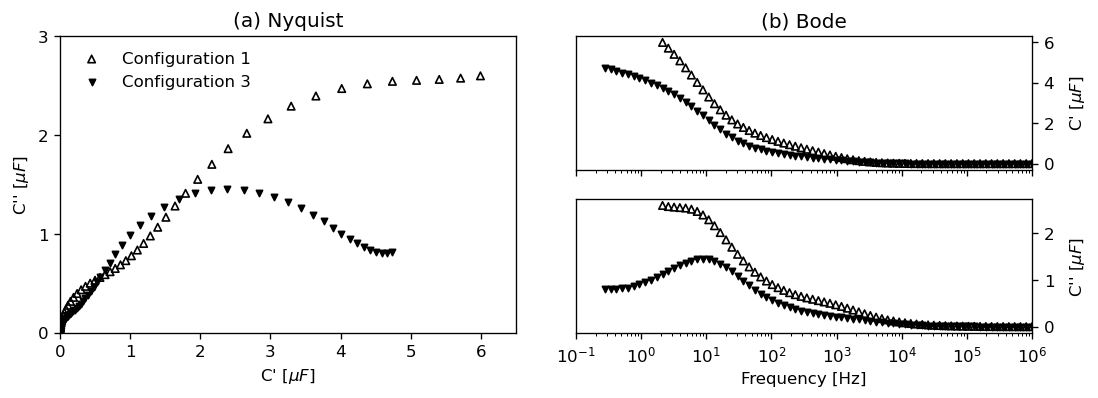

In [11]:
figure = plot_supplementary_figure_4(DATA_ROOT, style=figure_config("supplementary_pair"))
plt.show()

## 13. Reproducibility boundaries

This notebook reproduces the supported plots from the stored released exports and regenerates the Figure 5 derived curve in memory. The repository is intentionally limited to the author-selected raw data for the 10 reliable bar measurements reported in the paper, plus the dummy-control exports. It does not reproduce instrument acquisition, electrode fabrication, the exact historical software environment, sample pairing decisions, or a statistical uncertainty analysis.

End!